Using SemEval 2020 Task 11 evaluation critique to measure how well our benchmark performs. Our methods/techniques compared to those used by others in the competition:

#### Subtask 1: Span Identification (SI)

| Category | Our System                          | Rank 1 (Team Hitachi)                      | Rank 2 (Team ApplicaAI)                   | Bottom Tier (e.g., Team WMD)                   |
| :--- |:------------------------------------|:-------------------------------------------|:------------------------------------------|:-----------------------------------------------|
| **Transformers** | RoBERTa (Base)                      | BERT, RoBERTa, XLNet, XLM, GPT-2           | RoBERTa                                   | BERT                                           |
| **Learning Models** | Token Classification Head           | Bi-LSTM, CRF                               | CRF                                       | Linear Head                                    |
| **Representations** | Transformer Embeddings              | Embeddings, PoS Tags, Named Entities (NEs) | Transformer Embeddings                    | Transformer Embeddings                         |
| **Misc. Techniques** | Ensemble (Cascade), Data Resampling | Ensemble                                   | Ensemble, Data Augmentation (Silver Data) | Ensemble, Data Augmentation (Back-translation) |
| **Best F1 Test Performance** | **53.76**                           | **51.55**                                  | **49.15**                                 | **0.3-37**                                     |

<br>

#### Subtask 2: Technique Classification (TC)

| Category                     | Our System                    | Rank 1 (Team ApplicaAI)                   | Rank 2 (Team aschern)                                       | Bottom Tier (Baselines)             |
|:-----------------------------|:------------------------------|:------------------------------------------|:------------------------------------------------------------|:------------------------------------|
| **Transformers**             | RoBERTa (Base)                | RoBERTa                                   | RoBERTa                                                     | *None (Traditional ML)*             |
| **Learning Models**          | Sequence Classification Head  | Linear Head                               | Linear Head                                                 | SVM / Logistic Regression           |
| **Representations**          | Positional Markers (`[SPAN]`) | Transformer Embeddings                    | Transformer Embeddings                                      | TF-IDF, Word/Char n-grams, Lexicons |
| **Misc. Techniques**         | Label Smoothing               | Ensemble, Data Augmentation (Silver Data) | Ensemble, Transfer Learning (from SI task), Post-processing | *None*                              |
| **Best F1 Test Performance** | **64.8**                      | **62.07**                                 | **62.01**                                                   | **19-40**                           |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn.functional as F
import zipfile
import shutil
import gdown
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification
from sklearn.metrics import classification_report

In [2]:
#Identify base directory to ensure portability
BASE_DIR = Path.cwd().resolve().parent
MODELS_DIR = BASE_DIR / "models"
DATA_PATH = BASE_DIR / "data" / "processed" / "semeval_tc_cleaned.csv"

SI_DIR = MODELS_DIR / "semeval_roberta_scanner"
SI_SPEC_DIR = MODELS_DIR / "semeval_roberta_scanner_specialist"
TC_DIR = MODELS_DIR / "semeval_roberta_classifier"

SI_MODEL_PATH = f"{os.fspath(SI_DIR.absolute())}"
SI_SPEC_PATH = f"{os.fspath(SI_SPEC_DIR.absolute())}"
TC_MODEL_PATH = f"{os.fspath(TC_DIR.absolute())}"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
test_df = pd.read_csv(DATA_PATH)
#Drop duplicate articles
articles_df = test_df[['article_id','text_content']].drop_duplicates(subset=['article_id'])

exclude = ['article_id', 'text_content', 'span_text', 'sentiment', 'punct_count', 'lexical_diversity', 'start', 'end']
label_cols = [c for c in test_df.columns if c not in exclude]
print(f"Loaded test dataset with {len(test_df)} spans.")

Loaded test dataset with 7587 spans.


In [4]:
#Run training notebooks if models are missing
REQUIRED_FILES = ["config.json", "model.safetensors"]

def model_exists(path):
    path = Path(path)
    has_weights = any(path.glob("*.bin")) or any(path.glob("*.safetensors"))
    return has_weights

if not model_exists(SI_MODEL_PATH):
    print("SI Model missing. Running training notebook...")
    %run 4.1-fp-semeval-si-modeling.ipynb
if not model_exists(TC_MODEL_PATH):
    print("TC Model missing. Running training notebook...")
    %run 4.2-fp-semeval-tc-modeling.ipynb

In [5]:
def get_si_metrics(predicted_spans, gold_spans):
    if not predicted_spans and not gold_spans:
        return 1.0, 1.0, 1.0
    if not predicted_spans or not gold_spans:
        return 0.0, 0.0, 0.0

    #Precision
    p_num = 0
    for s in predicted_spans:
        max_overlap = 0
        for t in gold_spans:
            intersect = max(0, min(s[1], t[1]) - max(s[0], t[0]))
            max_overlap = max(max_overlap, intersect / (s[1] - s[0]))
        p_num += max_overlap
    precision = p_num / len(predicted_spans)

    #Recall
    r_num = 0
    for t in gold_spans:
        max_overlap = 0
        for s in predicted_spans:
            intersect = max(0, min(s[1], t[1]) - max(s[0], t[0]))
            max_overlap = max(max_overlap, intersect / (t[1] - t[0]))
        r_num += max_overlap
    recall = r_num / len(gold_spans)

    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

In [6]:
#Load Base SI Model (RoBERTa token-classifier for span detection)
print(f"Loading Base SI Model from: {SI_MODEL_PATH}...")
si_tokenizer = AutoTokenizer.from_pretrained(SI_MODEL_PATH)
si_model = AutoModelForTokenClassification.from_pretrained(SI_MODEL_PATH, local_files_only=True).to(device)
si_model.eval()

#Load Specialist SI Model
print(f"Loading Specialist SI Model from: {SI_SPEC_PATH}...")
si_spec_model = AutoModelForTokenClassification.from_pretrained(SI_SPEC_PATH, local_files_only=True).to(device)
si_spec_model.eval()

Loading Base SI Model from: /Users/frankiepike/MADS_Projects/Claim-Aware_Propaganda_Scanner/models/semeval_roberta_scanner...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading Specialist SI Model from: /Users/frankiepike/MADS_Projects/Claim-Aware_Propaganda_Scanner/models/semeval_roberta_scanner_specialist...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForTokenClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (L

In [7]:
#Load TC Model (Technique Classification)
tc_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
tc_model = AutoModelForSequenceClassification.from_pretrained(TC_MODEL_PATH).to(device)
tc_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50267, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [12]:
def run_pipeline(text):
    #Identify spans
    inputs = si_tokenizer(text, return_tensors="pt", truncation=True, padding=True, return_offsets_mapping=True).to(device)
    offsets = inputs.pop("offset_mapping")[0]

    with torch.no_grad():
        #Get Base Model Predictions (3 classes: 0, 1, 2)
        base_outputs = si_model(**inputs)
        base_logits = base_outputs.logits
        base_preds = torch.argmax(base_logits, dim=-1)[0]

        #Get Specialist Model Predictions (2 classes: 0, 1)
        spec_outputs = si_spec_model(**inputs)
        spec_logits = spec_outputs.logits

        #Calculate Specialist Confidence (Softmax)
        spec_probs = F.softmax(spec_logits, dim=-1)[0]
        propaganda_prob = spec_probs[:, 1]

    #Initialize final predictions with base model's results
    final_preds = base_preds.clone()

    #CASCADE LOGIC: If base found nothing (0) AND specialist is confident (> threshold)
    #We set it to '1' (which is the 'Beginning' tag in the base model)
    mask = (base_preds == 0) & (propaganda_prob > 0.5)
    final_preds[mask] = 1

    #Extract spans from the combined predictions
    predicted_spans = []
    current_span = None

    for i, pred in enumerate(final_preds):
        label = pred.item()
        start, end = offsets[i]
        if start == end: continue

        #In BIO tagging: 1 is 'B' (Begin), 2 is 'I' (Inside)
        if label in [1, 2]:
            if current_span is None:
                current_span = [start.item(), end.item()]
            else:
                current_span[1] = end.item()
        else:
            if current_span:
                predicted_spans.append(tuple(current_span))
                current_span = None

    if current_span:
        predicted_spans.append(tuple(current_span))

    #Technique classification
    final_results = []
    for span in predicted_spans:
        span_text = text[span[0]:span[1]].strip()
        if not span_text: continue

        tc_inputs = tc_tokenizer(span_text, return_tensors="pt", truncation=True, padding=True).to(device)

        with torch.no_grad():
            tc_logits = tc_model(**tc_inputs).logits
            pred_class = torch.argmax(tc_logits, dim=1).item()

        #Get technique name from the model config
        tech_name = tc_model.config.id2label[pred_class]
        final_results.append({"span": span, "technique": tech_name})

    return final_results

Tracking performance

--3/17 8:12 PM: SI F1: 0.2175, Pipeline TC F1: 0.0790 (prioritizing recall in T1 and precision in T2)

--3/17 8:40 PM: SI F1: 0.4117, Pipeline TC F1: 0.3173 (still the old architecture for SI but prioritizing F1)

--3/18 2:15 PM: SI F1: 0.5121, Pipeline TC F1: 0.4788 (prioritizing F1, training more)

--3/20: 1:44 PM: SI F1: 0.5202, Pipeline TC F1: 0.4944 (adding cascade logic)

In [13]:
#Evaluating strict TC on gold spans for Radar Chart (SemEval Subtask TC Standard)

true_labels = []
pred_labels = []

#1. Run quick predictions strictly on gold spans
for _, g_row in test_df.iterrows():
    techs = [col for col in label_cols if g_row[col] == 1]
    if not techs:
        continue
    true_tech = techs[0].replace("_", " ").lower()
    true_labels.append(true_tech)

    span_text = str(g_row['span_text'])
    tc_inputs = tc_tokenizer(span_text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        tc_logits = tc_model(**tc_inputs).logits
        pred_class = torch.argmax(tc_logits, dim=1).item()

    pred_tech = tc_model.config.id2label[pred_class].replace("_", " ").lower()
    pred_labels.append(pred_tech)

# 2. Extract Per-Technique F1 Scores automatically via sklearn
report = classification_report(true_labels, pred_labels, output_dict=True, zero_division=0)

# 3. Map dataset/model raw names to clean presentation names
score_mapping = {
    "Loaded Language": report.get("loaded language", {}).get("f1-score", 0) * 100,
    "Name Calling, Labeling": report.get("name calling labeling", {}).get("f1-score", 0) * 100,
    "Repetition": report.get("repetition", {}).get("f1-score", 0) * 100,
    "Exaggeration, Minimisation": report.get("exaggeration minimisation", {}).get("f1-score", 0) * 100,
    "Doubt": report.get("doubt", {}).get("f1-score", 0) * 100,
    "Appeal to fear/prejudice": report.get("appeal to fear-prejudice", {}).get("f1-score", 0) * 100,
    "Flag-waving": report.get("flag-waving", {}).get("f1-score", 0) * 100,
    "Causal Oversimplification": report.get("causal oversimplification", {}).get("f1-score", 0) * 100,
    "Slogans": report.get("slogans", {}).get("f1-score", 0) * 100,
    "Appeal to authority": report.get("appeal to authority", {}).get("f1-score", 0) * 100,
    "Black-and-white Fallacy": report.get("black-and-white fallacy", {}).get("f1-score", 0) * 100,
    "Thought-terminating cliché": report.get("thought-terminating cliches", {}).get("f1-score", 0) * 100,
    "Whataboutism, Straw Men, Red Herring": report.get("whataboutism straw men red herring", {}).get("f1-score", 0) * 100,
    "Bandwagon": report.get("bandwagon reductio ad hitlerum", {}).get("f1-score", 0) * 100
}

# 4. Create DataFrame and map to SemEval 2020 Table 6 Results
semeval_competitors = {
    "Loaded Language": {"ApplicaAI": 77.12, "aschern": 77.02, "Hitachi": 75.64, "NLFIIT (Median)": 72.55},
    "Name Calling, Labeling": {"ApplicaAI": 74.38, "aschern": 75.65, "Hitachi": 74.20, "NLFIIT (Median)": 69.30},
    "Repetition": {"ApplicaAI": 54.55, "aschern": 53.38, "Hitachi": 37.88, "NLFIIT (Median)": 21.55},
    "Exaggeration, Minimisation": {"ApplicaAI": 33.59, "aschern": 32.65, "Hitachi": 34.58, "NLFIIT (Median)": 30.30},
    "Doubt": {"ApplicaAI": 56.23, "aschern": 59.44, "Hitachi": 63.43, "NLFIIT (Median)": 55.66},
    "Appeal to fear/prejudice": {"ApplicaAI": 45.49, "aschern": 41.78, "Hitachi": 38.94, "NLFIIT (Median)": 24.89},
    "Flag-waving": {"ApplicaAI": 69.43, "aschern": 66.35, "Hitachi": 68.02, "NLFIIT (Median)": 63.32},
    "Causal Oversimplification": {"ApplicaAI": 22.73, "aschern": 25.97, "Hitachi": 36.62, "NLFIIT (Median)": 0.00},
    "Slogans": {"ApplicaAI": 51.28, "aschern": 54.24, "Hitachi": 45.61, "NLFIIT (Median)": 41.67},
    "Appeal to authority": {"ApplicaAI": 48.15, "aschern": 35.29, "Hitachi": 40.00, "NLFIIT (Median)": 29.63},
    "Black-and-white Fallacy": {"ApplicaAI": 49.02, "aschern": 53.57, "Hitachi": 47.92, "NLFIIT (Median)": 32.10},
    "Thought-terminating cliché": {"ApplicaAI": 39.22, "aschern": 42.55, "Hitachi": 29.41, "NLFIIT (Median)": 13.64},
    "Whataboutism, Straw Men, Red Herring": {"ApplicaAI": 25.00, "aschern": 18.87, "Hitachi": 26.92, "NLFIIT (Median)": 0.00},
    "Bandwagon": {"ApplicaAI": 8.33, "aschern": 14.93, "Hitachi": 4.88, "NLFIIT (Median)": 9.30}
}

df_comparison = pd.DataFrame(semeval_competitors).T
df_comparison.insert(0, "Our TC Model", [score_mapping.get(tech, 0.0) for tech in df_comparison.index])

display(df_comparison)

,Our TC Model,ApplicaAI,aschern,Hitachi,NLFIIT (Median)
Loaded Language,60.434681,77.12,77.02,75.64,72.55
"Name Calling, Labeling",0.000000,74.38,75.65,74.20,69.30
Repetition,13.215859,54.55,53.38,37.88,21.55
"Exaggeration, Minimisation",0.000000,33.59,32.65,34.58,30.30
Doubt,53.562654,56.23,59.44,63.43,55.66
Appeal to fear/prejudice,0.000000,45.49,41.78,38.94,24.89
Flag-waving,48.093842,69.43,66.35,68.02,63.32
Causal Oversimplification,24.356436,22.73,25.97,36.62,0.00
Slogans,0.000000,51.28,54.24,45.61,41.67
Appeal to authority,18.320611,48.15,35.29,40.00,29.63


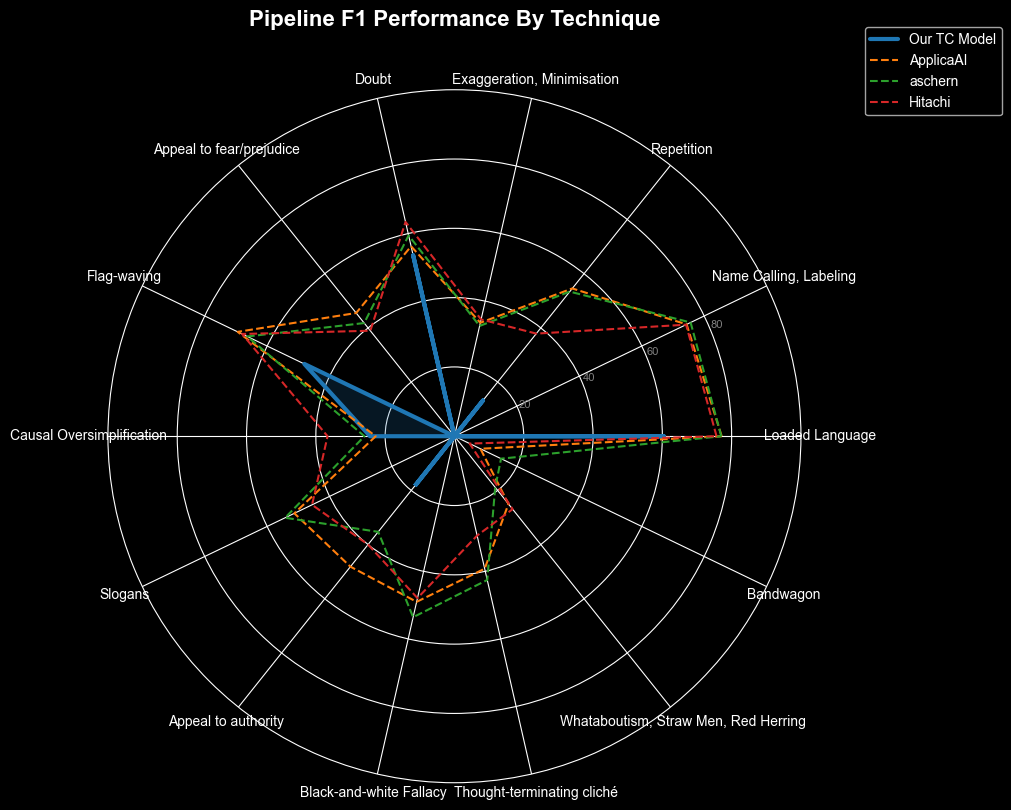

In [16]:
#Prepare data for radar chart
categories = df_comparison.index.tolist()
N = len(categories)

#Determine the angles for each technique radially
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

#Set colors (Blue for our pipeline, then varying colors for competitors)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
teams = df_comparison.columns

for color, team in zip(colors, teams):
    values = df_comparison[team].tolist()
    values += values[:1] # close the circle

    # UPDATE STRING HERE:
    linewidth = 3 if team == 'Our TC Model' else 1.5
    linestyle = '-' if team == 'Our TC Model' else '--'

    ax.plot(angles, values, color=color, linewidth=linewidth, linestyle=linestyle, label=team)

    if team == 'Our TC Model':
        ax.fill(angles, values, color=color, alpha=0.20)

#Apply formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10, wrap=True)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(["20", "40", "60", "80"], color="grey", size=8)

plt.title('Pipeline F1 Performance By Technique', size=16, weight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

#plt.savefig("radar_chart_comparison.png", bbox_inches='tight')

In [15]:
#Scoring
TOLERANCE = 10        #Forgive span boundaries off by this many characters
PARTIAL_CREDIT = 0.5 #Credit for finding propaganda, but wrong technique
FULL_CREDIT = 1.0    #Credit for right span AND right technique

global_custom_p_num, global_custom_p_den = 0, 0
global_custom_r_num, global_custom_r_den = 0, 0

print(f"Evaluating Realistic Pipeline on {test_df['article_id'].nunique()} articles...")

for _, row in articles_df.iterrows():
    article_id = row['article_id']
    full_text = row['text_content']

    #1. Get gold labels
    gold_rows = test_df[test_df['article_id'] == article_id]
    gold_data = []
    for _, g_row in gold_rows.iterrows():
        techs = [col for col in label_cols if g_row[col] == 1]
        if 'start' in g_row and pd.notna(g_row['start']):
            s, e = int(g_row['start']), int(g_row['end'])
        else:
            s = full_text.find(str(g_row['span_text']))
            e = s + len(str(g_row['span_text']))

        if s != -1:
            for t in techs:
                gold_data.append({"span": (s, e), "tech": t})

    #2. Run predictions
    predictions = run_pipeline(full_text)

    #3. Custom Precision: Did the model's predictions match reality?
    global_custom_p_den += len(predictions)
    for p in predictions:
        best_score = 0
        p_tech_clean = p['technique'].replace("_", " ").lower()

        for g in gold_data:
            g_tech_clean = g['tech'].replace("_", " ").lower()

            #Check boundaries against tolerance
            start_diff = abs(p['span'][0] - g['span'][0])
            end_diff = abs(p['span'][1] - g['span'][1])

            if start_diff <= TOLERANCE and end_diff <= TOLERANCE:
                if p_tech_clean == g_tech_clean:
                    best_score = max(best_score, FULL_CREDIT)
                else:
                    best_score = max(best_score, PARTIAL_CREDIT)

        global_custom_p_num += best_score

    #4. Custom Recall: Did the model find the true gold spans?
    global_custom_r_den += len(gold_data)
    for g in gold_data:
        best_score = 0
        g_tech_clean = g['tech'].replace("_", " ").lower()

        for p in predictions:
            p_tech_clean = p['technique'].replace("_", " ").lower()

            start_diff = abs(p['span'][0] - g['span'][0])
            end_diff = abs(p['span'][1] - g['span'][1])

            if start_diff <= TOLERANCE and end_diff <= TOLERANCE:
                if p_tech_clean == g_tech_clean:
                    best_score = max(best_score, FULL_CREDIT)
                else:
                    best_score = max(best_score, PARTIAL_CREDIT)

        global_custom_r_num += best_score

#Calculate Final Realistic Scores
custom_p = global_custom_p_num / global_custom_p_den if global_custom_p_den > 0 else 0
custom_r = global_custom_r_num / global_custom_r_den if global_custom_r_den > 0 else 0
custom_f1 = (2 * custom_p * custom_r / (custom_p + custom_r)) if (custom_p + custom_r) > 0 else 0

print("\n" + "="*45)
print(f"Realistic Pipeline Precision: {custom_p:.4f}")
print(f"Realistic Pipeline Recall:    {custom_r:.4f}")
print(f"Realistic Pipeline F1 Score:  {custom_f1:.4f}")
print("="*45)

Evaluating Realistic Pipeline on 357 articles...

Realistic Pipeline Precision: 0.3260
Realistic Pipeline Recall:    0.1609
Realistic Pipeline F1 Score:  0.2154


Performance with old best TC model: Realistic Pipeline Precision: 0.3260
Realistic Pipeline Recall:    0.1609
Realistic Pipeline F1 Score:  0.2154